<a href="https://colab.research.google.com/github/yaraabdalkreemismaiel-art/SmartDeskAI/blob/main/notebooks/posture_feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

`**تجهيز بيئة العمل**`

In [1]:
!pip install mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 12.8 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [2]:
import cv2
import mediapipe as mp

print("OpenCV version:", cv2.__version__)
print("MediaPipe imported successfully")

OpenCV version: 5.0.0
MediaPipe imported successfully


In [3]:
import cv2
import matplotlib.pyplot as plt

print("Libraries imported")

Libraries imported


`**تشغيل صورة واحدة**`

In [358]:
image = cv2.imread("P2_slouched_back.png")

print(type(image))
print(image.shape)

<class 'numpy.ndarray'>
(390, 486, 3)


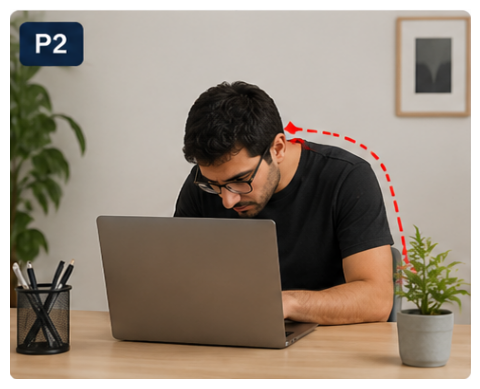

In [359]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off");

`**  MediaPipe Poseاستخدام**`
(Body Landmarks)اكتشاف جسم الانسان واستخراج نقاط الجسم

In [360]:
import sys
import mediapipe as mp

print("Python:", sys.version)
print("MediaPipe:", getattr(mp, "__version__", "unknown"))
print("MediaPipe path:", mp.__file__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
MediaPipe: 1.0.0
MediaPipe path: /usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py


In [361]:
import mediapipe as mp

print("MediaPipe version:", mp.__version__)

print("Tasks available:", hasattr(mp, "tasks"))

MediaPipe version: 1.0.0
Tasks available: True


In [362]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

print("Pose Landmarker API is available")

Pose Landmarker API is available


In [364]:
!wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task

In [365]:
import os

print(os.path.exists("pose_landmarker_full.task"))

True


Pose Landmarkerانشاء

In [367]:
base_options = python.BaseOptions(
    model_asset_path="pose_landmarker_full.task"
)

options = vision.PoseLandmarkerOptions(
    base_options=base_options
)

landmarker = vision.PoseLandmarker.create_from_options(options)

print("Pose Landmarker is ready")

Pose Landmarker is ready


In [368]:
import os

print(os.listdir())

['.config', 'P5_uneven_shoulders.png', 'person sitting on chair.jpg', 'person.jfif', 'test3.jpg', 'test.jpg', 'P2_slouched_back.png', 'P4_head_tilt_left.png', 'pose_landmarker_full.task.4', 'pose_landmarker_full.task.1', 'pose_landmarker_full.task.3', 'P1_head_forward.png', 'pose_landmarker_full.task', '.ipynb_checkpoints', 'pose_landmarker_full.task.2', 'P3_head_tilt_right.png', 'test2.jpg', 'pose_landmarker_full.task.7', 'pose_landmarker_full.task.5', 'test4.jpg', 'pose_landmarker_full.task.6', 'sample_data']


In [369]:
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

print("Image converted to RGB")

Image converted to RGB


In [370]:
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=image_rgb
)

print("Image converted to MediaPipe format")

Image converted to MediaPipe format


In [371]:
result = landmarker.detect(mp_image)

print("Inference completed")

Inference completed


In [372]:
print("Number of detected people:", len(result.pose_landmarks))

Number of detected people: 1


In [373]:
landmarks = result.pose_landmarks[0]

print("Number of landmarks:", len(landmarks))

Number of landmarks: 33


    على الصورةlandMarks 33 رسم الـ

In [374]:
from mediapipe.tasks.python.vision import drawing_utils

In [375]:
height, width, _ = image.shape

print("Width:", width)
print("Height:", height)

Width: 486
Height: 390


In [376]:
import cv2
import matplotlib.pyplot as plt

image_with_landmarks = image.copy()

for landmark in landmarks:
    x = int(landmark.x * width)
    y = int(landmark.y * height)

    cv2.circle(
        image_with_landmarks,
        (x, y),
        5,
        (0, 255, 0),
        -1
    )

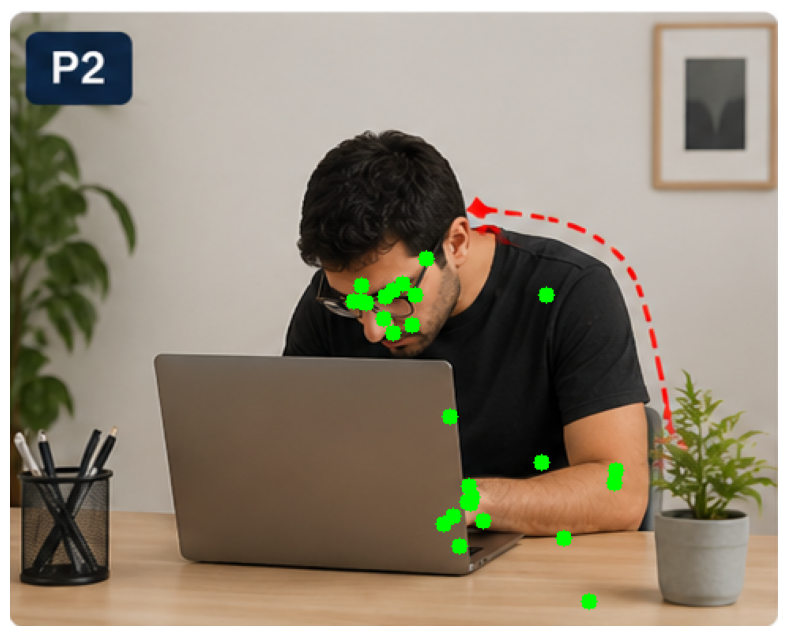

In [377]:
plt.figure(figsize=(10, 8))

plt.imshow(
    cv2.cvtColor(image_with_landmarks, cv2.COLOR_BGR2RGB)
)

plt.axis("off");

In [378]:
from mediapipe.tasks.python.vision import PoseLandmark

In [379]:
for landmark in PoseLandmark:
    print(landmark.value, landmark.name)

0 NOSE
1 LEFT_EYE_INNER
2 LEFT_EYE
3 LEFT_EYE_OUTER
4 RIGHT_EYE_INNER
5 RIGHT_EYE
6 RIGHT_EYE_OUTER
7 LEFT_EAR
8 RIGHT_EAR
9 MOUTH_LEFT
10 MOUTH_RIGHT
11 LEFT_SHOULDER
12 RIGHT_SHOULDER
13 LEFT_ELBOW
14 RIGHT_ELBOW
15 LEFT_WRIST
16 RIGHT_WRIST
17 LEFT_PINKY
18 RIGHT_PINKY
19 LEFT_INDEX
20 RIGHT_INDEX
21 LEFT_THUMB
22 RIGHT_THUMB
23 LEFT_HIP
24 RIGHT_HIP
25 LEFT_KNEE
26 RIGHT_KNEE
27 LEFT_ANKLE
28 RIGHT_ANKLE
29 LEFT_HEEL
30 RIGHT_HEEL
31 LEFT_FOOT_INDEX
32 RIGHT_FOOT_INDEX


In [380]:
nose = landmarks[0]

print("Nose X:", nose.x)
print("Nose Y:", nose.y)
print("Nose Z:", nose.z)
print("Nose visibility:", nose.visibility)

Nose X: 0.48753583431243896
Nose Y: 0.5023089647293091
Nose Z: -0.7831759452819824
Nose visibility: 0.9982708692550659


In [381]:
left_shoulder = landmarks[11]

print("Left Shoulder X:", left_shoulder.x)
print("Left Shoulder Y:", left_shoulder.y)
print("Left Shoulder Z:", left_shoulder.z)
print("Left Shoulder visibility:", left_shoulder.visibility)

Left Shoulder X: 0.6984928846359253
Left Shoulder Y: 0.46367982029914856
Left Shoulder Z: -0.7613911032676697
Left Shoulder visibility: 0.9986205101013184


In [382]:
print("Number of landmarks:", len(landmarks))

for i, landmark in enumerate(landmarks):
    print(
        i,
        "x =", round(landmark.x, 3),
        "y =", round(landmark.y, 3),
        "z =", round(landmark.z, 3),
        "visibility =", round(landmark.visibility, 3)
    )

Number of landmarks: 33
0 x = 0.488 y = 0.502 z = -0.783 visibility = 0.998
1 x = 0.489 y = 0.464 z = -0.817 visibility = 0.999
2 x = 0.499 y = 0.456 z = -0.817 visibility = 0.999
3 x = 0.511 y = 0.445 z = -0.817 visibility = 0.999
4 x = 0.464 y = 0.475 z = -0.77 visibility = 0.998
5 x = 0.456 y = 0.474 z = -0.77 visibility = 0.997
6 x = 0.448 y = 0.473 z = -0.771 visibility = 0.997
7 x = 0.542 y = 0.404 z = -0.817 visibility = 0.999
8 x = 0.458 y = 0.448 z = -0.608 visibility = 0.998
9 x = 0.523 y = 0.512 z = -0.768 visibility = 0.999
10 x = 0.499 y = 0.524 z = -0.708 visibility = 0.998
11 x = 0.698 y = 0.464 z = -0.761 visibility = 0.999
12 x = 0.527 y = 0.464 z = -0.386 visibility = 0.993
13 x = 0.787 y = 0.769 z = -0.732 visibility = 0.971
14 x = 0.573 y = 0.661 z = -0.226 visibility = 0.066
15 x = 0.617 y = 0.829 z = -0.646 visibility = 0.919
16 x = 0.599 y = 0.774 z = -0.183 visibility = 0.044
17 x = 0.585 y = 0.87 z = -0.696 visibility = 0.811
18 x = 0.6 y = 0.801 z = -0.18 visi

In [383]:
landmark_names = [
    "Nose",
    "Left Eye Inner",
    "Left Eye",
    "Left Eye Outer",
    "Right Eye Inner",
    "Right Eye",
    "Right Eye Outer",
    "Left Ear",
    "Right Ear",
    "Mouth Left",
    "Mouth Right",
    "Left Shoulder",
    "Right Shoulder",
    "Left Elbow",
    "Right Elbow",
    "Left Wrist",
    "Right Wrist",
    "Left Pinky",
    "Right Pinky",
    "Left Index",
    "Right Index",
    "Left Thumb",
    "Right Thumb",
    "Left Hip",
    "Right Hip",
    "Left Knee",
    "Right Knee",
    "Left Ankle",
    "Right Ankle",
    "Left Heel",
    "Right Heel",
    "Left Foot Index",
    "Right Foot Index"
]

for i in [0, 11, 12, 13, 14, 23, 24, 25, 26]:
    lm = landmarks[i]
    print(
        f"{i:2d} | {landmark_names[i]:15s} | "
        f"x={lm.x:.3f} | y={lm.y:.3f} | "
        f"z={lm.z:.3f} | visibility={lm.visibility:.3f}"
    )

 0 | Nose            | x=0.488 | y=0.502 | z=-0.783 | visibility=0.998
11 | Left Shoulder   | x=0.698 | y=0.464 | z=-0.761 | visibility=0.999
12 | Right Shoulder  | x=0.527 | y=0.464 | z=-0.386 | visibility=0.993
13 | Left Elbow      | x=0.787 | y=0.769 | z=-0.732 | visibility=0.971
14 | Right Elbow     | x=0.573 | y=0.661 | z=-0.226 | visibility=0.066
23 | Left Hip        | x=0.789 | y=0.749 | z=-0.109 | visibility=0.998
24 | Right Hip       | x=0.692 | y=0.735 | z=0.109 | visibility=0.994
25 | Left Knee       | x=0.753 | y=0.959 | z=-0.067 | visibility=0.356
26 | Right Knee      | x=0.721 | y=0.857 | z=0.294 | visibility=0.087


features: 1)المسافة بين الكتفين

In [384]:
import math

left_shoulder = landmarks[11]
right_shoulder = landmarks[12]

shoulder_distance = math.sqrt(
    (right_shoulder.x - left_shoulder.x)**2 +
    (right_shoulder.y - left_shoulder.y)**2
)

print("Shoulder distance:", shoulder_distance)

Shoulder distance: 0.17153293332801126


features: 2)المسافة بين الوركين

In [385]:
left_hip = landmarks[23]
right_hip = landmarks[24]

hip_distance = math.sqrt(
    (right_hip.x - left_hip.x)**2 +
    (right_hip.y - left_hip.y)**2
)

print("Hip distance:", hip_distance)

Hip distance: 0.0980406937387338


نسبة الكتفين الى الوركين(3

In [386]:
shoulder_hip_ratio = shoulder_distance / hip_distance

print("Shoulder/Hip ratio:", shoulder_hip_ratio)

Shoulder/Hip ratio: 1.749609542595905


4)ميل الكتفين

In [387]:
shoulder_y_difference = abs(
    left_shoulder.y - right_shoulder.y
)

print("Shoulder Y difference:", shoulder_y_difference)

Shoulder Y difference: 0.00025069713592529297


In [388]:
shoulder_y_difference = abs(
    left_shoulder.y - right_shoulder.y
)

print("Shoulder Y difference:", shoulder_y_difference)

Shoulder Y difference: 0.00025069713592529297


### 5)  موقع الأنف أفقياً بالنسبة لمركز الكتفين
### 6) موقع الأنف عمودياً بالنسبة لمركز الكتفين

In [389]:
# Get the center point between the two shoulders

shoulder_center_x = (
    left_shoulder.x + right_shoulder.x
) / 2

shoulder_center_y = (
    left_shoulder.y + right_shoulder.y
) / 2

print("Shoulder center X:", shoulder_center_x)
print("Shoulder center Y:", shoulder_center_y)

Shoulder center X: 0.6127265095710754
Shoulder center Y: 0.4638051688671112


In [390]:
# Difference between the nose and the shoulder center

head_shoulder_dx = nose.x - shoulder_center_x
head_shoulder_dy = nose.y - shoulder_center_y

print("Head-Shoulder X difference:", head_shoulder_dx)
print("Head-Shoulder Y difference:", head_shoulder_dy)

Head-Shoulder X difference: -0.12519067525863647
Head-Shoulder Y difference: 0.038503795862197876


In [391]:
# ==========================================
# Head-Shoulder Z Difference
# ==========================================

nose = landmarks[0]

left_shoulder = landmarks[11]
right_shoulder = landmarks[12]

# Shoulder center Z
shoulder_center_z = (
    left_shoulder.z + right_shoulder.z
) / 2

# Head-Shoulder Z difference
head_shoulder_dz = nose.z - shoulder_center_z

print("Nose Z:", nose.z)
print("Shoulder Center Z:", shoulder_center_z)
print("Head-Shoulder Z difference:", head_shoulder_dz)

Nose Z: -0.7831759452819824
Shoulder Center Z: -0.5734546184539795
Head-Shoulder Z difference: -0.20972132682800293


5)وضعية الرأس Head Tilt

In [393]:
# Head tilt based on ear positions

right_ear = landmarks[7]
left_ear = landmarks[8]

head_tilt_y_difference = abs(
    right_ear.y - left_ear.y
)

print("Head tilt Y difference:", head_tilt_y_difference)

Head tilt Y difference: 0.04369485378265381


In [394]:
# ==========================================
# Normalize posture-related features
# using shoulder distance as scale
# ==========================================

normalized_shoulder_y_difference = (
    shoulder_y_difference / shoulder_distance
)

normalized_head_shoulder_dx = (
    head_shoulder_dx / shoulder_distance
)

normalized_head_shoulder_dy = (
    head_shoulder_dy / shoulder_distance
)

normalized_head_tilt = (
    head_tilt_y_difference / shoulder_distance
)

print("Shoulder Distance:", shoulder_distance)

print(
    "Normalized Shoulder Y difference:",
    normalized_shoulder_y_difference
)

print(
    "Normalized Head-Shoulder X difference:",
    normalized_head_shoulder_dx
)

print(
    "Normalized Head-Shoulder Y difference:",
    normalized_head_shoulder_dy
)

print(
    "Normalized Head Tilt:",
    normalized_head_tilt
)

Shoulder Distance: 0.17153293332801126
Normalized Shoulder Y difference: 0.0014615102246628125
Normalized Head-Shoulder X difference: -0.7298346319260016
Normalized Head-Shoulder Y difference: 0.2244688242377898
Normalized Head Tilt: 0.25473157215296366


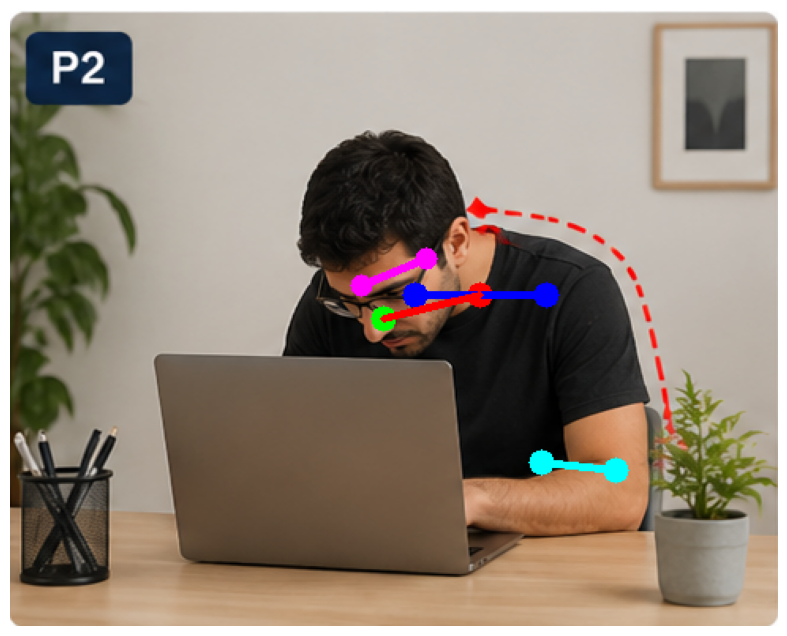

In [395]:
import cv2
import matplotlib.pyplot as plt

# Copy original image
image_features = image.copy()

# Convert normalized coordinates to pixels
def to_pixel(landmark):
    return (
        int(landmark.x * width),
        int(landmark.y * height)
    )

# Get important landmarks
nose = landmarks[0]

left_shoulder = landmarks[11]
right_shoulder = landmarks[12]

left_hip = landmarks[23]
right_hip = landmarks[24]

right_ear = landmarks[7]
left_ear = landmarks[8]

# Pixel coordinates
nose_px = to_pixel(nose)

left_shoulder_px = to_pixel(left_shoulder)
right_shoulder_px = to_pixel(right_shoulder)

left_hip_px = to_pixel(left_hip)
right_hip_px = to_pixel(right_hip)

right_ear_px = to_pixel(right_ear)
left_ear_px = to_pixel(left_ear)

# Shoulder center
shoulder_center_x = (
    left_shoulder.x + right_shoulder.x
) / 2

shoulder_center_y = (
    left_shoulder.y + right_shoulder.y
) / 2

shoulder_center_px = (
    int(shoulder_center_x * width),
    int(shoulder_center_y * height)
)

# -------------------------
# Draw points
# -------------------------

# Nose
cv2.circle(image_features, nose_px, 8, (0, 255, 0), -1)

# Shoulders
cv2.circle(image_features, left_shoulder_px, 8, (255, 0, 0), -1)
cv2.circle(image_features, right_shoulder_px, 8, (255, 0, 0), -1)

# Shoulder center
cv2.circle(image_features, shoulder_center_px, 8, (0, 0, 255), -1)

# Hips
cv2.circle(image_features, left_hip_px, 8, (255, 255, 0), -1)
cv2.circle(image_features, right_hip_px, 8, (255, 255, 0), -1)

# Ears
cv2.circle(image_features, right_ear_px, 7, (255, 0, 255), -1)
cv2.circle(image_features, left_ear_px, 7, (255, 0, 255), -1)

# -------------------------
# Draw feature relationships
# -------------------------

# Shoulder distance
cv2.line(
    image_features,
    left_shoulder_px,
    right_shoulder_px,
    (255, 0, 0),
    3
)

# Hip distance
cv2.line(
    image_features,
    left_hip_px,
    right_hip_px,
    (255, 255, 0),
    3
)

# Nose → Shoulder Center
cv2.line(
    image_features,
    nose_px,
    shoulder_center_px,
    (0, 0, 255),
    3
)

# Ear → Ear (Head Tilt)
cv2.line(
    image_features,
    left_ear_px,
    right_ear_px,
    (255, 0, 255),
    3
)

# -------------------------
# Display
# -------------------------

plt.figure(figsize=(10, 8))

plt.imshow(
    cv2.cvtColor(image_features, cv2.COLOR_BGR2RGB)
)

plt.axis("off");

In [396]:
# ==========================================
# Create the normalized posture feature vector
# ==========================================

posture_features = [
    shoulder_distance,
    normalized_shoulder_y_difference,
    normalized_head_shoulder_dx,
    normalized_head_shoulder_dy,
    normalized_head_tilt
]

print("Posture Feature Vector:")
print(posture_features)

print("\nNumber of features:", len(posture_features))

Posture Feature Vector:
[0.17153293332801126, 0.0014615102246628125, -0.7298346319260016, 0.2244688242377898, 0.25473157215296366]

Number of features: 5


In [397]:
import cv2
import numpy as np
import pandas as pd


def extract_posture_features(image_path, label, image_name):

    # -----------------------------------
    # 1. Read image
    # -----------------------------------
    image = cv2.imread(image_path)

    if image is None:
        print("Could not read:", image_path)
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # -----------------------------------
    # 2. Convert to MediaPipe Image
    # -----------------------------------
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=image_rgb
    )

    # -----------------------------------
    # 3. Run Pose Landmarker
    # -----------------------------------
    result = landmarker.detect(mp_image)

    if not result.pose_landmarks:
        print("No pose detected:", image_name)
        return None

    landmarks = result.pose_landmarks[0]

    # -----------------------------------
    # 4. Select landmarks
    # -----------------------------------
    nose = landmarks[0]

    left_eye = landmarks[2]
    right_eye = landmarks[5]

    left_shoulder = landmarks[11]
    right_shoulder = landmarks[12]

    # -----------------------------------
    # 5. Shoulder distance
    # -----------------------------------
    shoulder_distance = np.sqrt(
        (left_shoulder.x - right_shoulder.x)**2 +
        (left_shoulder.y - right_shoulder.y)**2
    )

    # -----------------------------------
    # 6. Shoulder Y difference
    # -----------------------------------
    shoulder_y_difference = abs(
        left_shoulder.y - right_shoulder.y
    )

    normalized_shoulder_y = (
        shoulder_y_difference / shoulder_distance
    )

    # -----------------------------------
    # 7. Shoulder center
    # -----------------------------------
    shoulder_center_x = (
        left_shoulder.x + right_shoulder.x
    ) / 2

    shoulder_center_y = (
        left_shoulder.y + right_shoulder.y
    ) / 2

    shoulder_center_z = (
        left_shoulder.z + right_shoulder.z
    ) / 2

    # -----------------------------------
    # 8. Head-Shoulder X
    # -----------------------------------
    head_shoulder_dx = (
        nose.x - shoulder_center_x
    )

    normalized_head_x = (
        head_shoulder_dx / shoulder_distance
    )

    # -----------------------------------
    # 9. Head-Shoulder Y
    # -----------------------------------
    head_shoulder_dy = (
        nose.y - shoulder_center_y
    )

    normalized_head_y = (
        head_shoulder_dy / shoulder_distance
    )

    # -----------------------------------
    # 10. Head tilt
    # -----------------------------------
    head_tilt_y_difference = abs(
        left_eye.y - right_eye.y
    )

    normalized_head_tilt = (
        head_tilt_y_difference / shoulder_distance
    )

    # -----------------------------------
    # 11. Head-Shoulder Z
    # -----------------------------------
    head_shoulder_dz = (
        nose.z - shoulder_center_z
    )

    # -----------------------------------
    # 12. Final result
    # -----------------------------------
    return {
        "Image": image_name,
        "Label": label,
        "Shoulder Dist.": shoulder_distance,
        "Shoulder Y": normalized_shoulder_y,
        "Head X": normalized_head_x,
        "Head Y": normalized_head_y,
        "Head Tilt": normalized_head_tilt,
        "Head-Shoulder Z": head_shoulder_dz
    }

In [400]:
# ==========================================
# Process 10 images: Good + Poor
# ==========================================

images = [
    # Good posture
    ("G1.png", "Good", "G1"),
    ("G2.png", "Good", "G2"),
    ("G3.png", "Good", "G3"),
    ("G4.png", "Good", "G4"),
    ("G5.png", "Good", "G5"),

    # Poor posture
    ("P1_head_forward.png", "Poor", "P1"),
    ("P2_slouched_back.png", "Poor", "P2"),
    ("P3_head_tilt_right.png", "Poor", "P3"),
    ("P4_head_tilt_left.png", "Poor", "P4"),
    ("P5_uneven_shoulders.png", "Poor", "P5")
]

results = []

for image_path, label, image_name in images:

    features = extract_posture_features(
        image_path=image_path,
        label=label,
        image_name=image_name
    )

    if features is not None:
        results.append(features)


# Create DataFrame
posture_df = pd.DataFrame(results)

# Display the table
posture_df

,Image,Label,Shoulder Dist.,Shoulder Y,Head X,Head Y,Head Tilt,Head-Shoulder Z
0,G1,Good,0.349654,0.010826,0.026872,-0.649352,0.003283,-0.508738
1,G2,Good,0.316256,0.039948,0.030291,-0.696762,0.000992,-0.682694
2,G3,Good,0.334600,0.016197,0.032620,-0.679726,0.004138,-0.563071
3,G4,Good,0.307878,0.014756,0.024284,-0.692775,0.010981,-0.548821
4,G5,Good,0.332885,0.036917,0.027326,-0.686024,0.002795,-0.609130
5,P1,Poor,0.293493,0.121351,-0.057855,0.069251,0.013554,-0.496427
6,P2,Poor,0.171533,0.001462,-0.729835,0.224469,0.105829,-0.209721
7,P3,Poor,0.346733,0.008260,0.119556,-0.395866,0.107476,-0.427288
8,P4,Poor,0.349025,0.026413,0.222532,-0.350619,0.127332,-0.375479
9,P5,Poor,0.355503,0.024132,0.085430,-0.351333,0.058271,-0.473208
